# Fertilizer Recommendation System

## 1. Importing Libraries

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

## 2. Importing Dataset

In [109]:
dataset = pd.read_csv("/content/Fertilizer_Recommendation_Dataset_Kaggle_Format-6.csv")
display(dataset.head())

,ID,Temperature (°C),Humidity (%),Soil Moisture (%),Soil Type,Crop Type,Nitrogen (kg/ha),Phosphorus (kg/ha),Potassium (kg/ha),Recommended Fertilizer
0,1,21,62,30,Red,Sugarcane,26,17,39,Urea 46-0-0
1,2,37,80,46,Black,Wheat,30,23,36,Urea 46-0-0
2,3,37,66,40,Loamy,Wheat,47,20,39,DAP 18-46-0
3,4,22,45,45,Red,Rice,22,20,24,Urea 46-0-0
4,5,24,46,43,Red,Millet,36,45,17,NPK 10-26-26


## 3. Preprocessing: Label Encoding Categorical Features

In [110]:
le_soil = LabelEncoder()
le_crop = LabelEncoder()

dataset['Soil Type'] = le_soil.fit_transform(dataset['Soil Type'])
dataset['Crop Type'] = le_crop.fit_transform(dataset['Crop Type'])

print("Crop Type Mapping:")
for i, crop in enumerate(le_crop.classes_):
    print(crop, "=", i)

print("\nSoil Type Mapping:")
for i, soil in enumerate(le_soil.classes_):
    print(soil, "=", i)

Crop Type Mapping:
Barley = 0
Cotton = 1
Groundnut = 2
Maize = 3
Millet = 4
Paddy = 5
Rice = 6
Sugarcane = 7
Wheat = 8

Soil Type Mapping:
Black = 0
Clayey = 1
Loamy = 2
Red = 3
Sandy = 4


## 4. Feature Selection and Data Splitting

In [111]:
X = dataset[['Temperature (°C)', 'Humidity (%)', 'Soil Moisture (%)',
             'Soil Type', 'Crop Type',
             'Nitrogen (kg/ha)', 'Phosphorus (kg/ha)', 'Potassium (kg/ha)']].values

Y = dataset['Recommended Fertilizer'].values

X_Train, X_Test, Y_Train, Y_Test = train_test_split(
    X, Y, test_size=0.25, random_state=0
)

## 5. Feature Scaling

In [112]:
sc_X = StandardScaler()
X_Train = sc_X.fit_transform(X_Train)
X_Test = sc_X.transform(X_Test)

## 6. Model Training and Evaluation (Original Models)

### 6.1 Decision Tree Classifier (Original Configuration)

In [113]:
model_dt_original = DecisionTreeClassifier(criterion="entropy",max_depth=None,
                                min_samples_split=5, min_samples_leaf=2, random_state=0)

model_dt_original.fit(X_Train, Y_Train)
print("Decision Tree (Original) Model:\n", model_dt_original)

y_pred_dt_original = model_dt_original.predict(X_Test)

cm_dt_original = confusion_matrix(Y_Test, y_pred_dt_original)
print("\nConfusion Matrix (Decision Tree Original):\n", cm_dt_original)

acc_dt_original = accuracy_score(Y_Test, y_pred_dt_original)
precision_dt_original = precision_score(Y_Test, y_pred_dt_original, average='weighted', zero_division=0)
recall_dt_original = recall_score(Y_Test, y_pred_dt_original, average='weighted', zero_division=0)

print(f"\nDecision Tree (Original) Accuracy: {acc_dt_original:.4f}")
print(f"Decision Tree (Original) Precision: {precision_dt_original:.4f}")
print(f"Decision Tree (Original) Recall: {recall_dt_original:.4f}")

Decision Tree (Original) Model:
 DecisionTreeClassifier(criterion='entropy', min_samples_leaf=2,
                       min_samples_split=5, random_state=0)

Confusion Matrix (Decision Tree Original):
 [[11  0  0  0  0]
 [ 0  4  0  0  0]
 [ 0  0  2  2  0]
 [ 0  0  1  8  0]
 [ 0  0  0  0 10]]

Decision Tree (Original) Accuracy: 0.9211
Decision Tree (Original) Precision: 0.9175
Decision Tree (Original) Recall: 0.9211


### 6.2 Logistic Regression

In [114]:
model_lr = LogisticRegression(random_state=0, max_iter=1000)
model_lr.fit(X_Train, Y_Train)
print("Logistic Regression Model:\n", model_lr)

y_pred_lr = model_lr.predict(X_Test)

cm_lr = confusion_matrix(Y_Test, y_pred_lr)
print("\nConfusion Matrix (Logistic Regression):\n", cm_lr)

acc_lr = accuracy_score(Y_Test, y_pred_lr)
precision_lr = precision_score(Y_Test, y_pred_lr, average='weighted', zero_division=0)
recall_lr = recall_score(Y_Test, y_pred_lr, average='weighted', zero_division=0)

print(f"\nLogistic Regression Accuracy: {acc_lr:.4f}")
print(f"Logistic Regression Precision: {precision_lr:.4f}")
print(f"Logistic Regression Recall: {recall_lr:.4f}")

Logistic Regression Model:
 LogisticRegression(max_iter=1000, random_state=0)

Confusion Matrix (Logistic Regression):
 [[8 0 0 3 0]
 [0 2 0 0 2]
 [0 0 0 4 0]
 [0 1 0 8 0]
 [0 0 0 1 9]]

Logistic Regression Accuracy: 0.7105
Logistic Regression Precision: 0.6934
Logistic Regression Recall: 0.7105


### 6.3 Random Forest Classifier (Original Configuration)

In [115]:
model_rf_original = RandomForestClassifier(n_estimators=200, criterion='entropy', random_state=0)
model_rf_original.fit(X_Train, Y_Train)

y_pred_rf_original = model_rf_original.predict(X_Test)

cm_rf_original = confusion_matrix(Y_Test, y_pred_rf_original)
print("\nConfusion Matrix (Random Forest Original):\n", cm_rf_original)

acc_rf_original = accuracy_score(Y_Test, y_pred_rf_original)
precision_rf_original = precision_score(Y_Test, y_pred_rf_original, average='weighted', zero_division=0)
recall_rf_original = recall_score(Y_Test, y_pred_rf_original, average='weighted', zero_division=0)

print(f"\nRandom Forest (Original) Accuracy: {acc_rf_original:.4f}")
print(f"Random Forest (Original) Precision: {precision_rf_original:.4f}")
print(f"Random Forest (Original) Recall: {recall_rf_original:.4f}")


Confusion Matrix (Random Forest Original):
 [[11  0  0  0  0]
 [ 0  4  0  0  0]
 [ 0  0  0  4  0]
 [ 0  1  0  8  0]
 [ 0  0  0  0 10]]

Random Forest (Original) Accuracy: 0.8684
Random Forest (Original) Precision: 0.7947
Random Forest (Original) Recall: 0.8684


### 6.4 Artificial Neural Network (ANN)

In [116]:
model_ann = MLPClassifier(hidden_layer_sizes=(6,6),
                      activation='relu',
                      solver='adam',
                      max_iter=1000,
                      random_state=0)

model_ann.fit(X_Train, Y_Train)
print("ANN Model:\n", model_ann)

y_pred_ann = model_ann.predict(X_Test)

cm_ann = confusion_matrix(Y_Test, y_pred_ann)
print("\nConfusion Matrix (ANN):\n", cm_ann)

acc_ann = accuracy_score(Y_Test, y_pred_ann)
precision_ann = precision_score(Y_Test, y_pred_ann, average='weighted', zero_division=0)
recall_ann = recall_score(Y_Test, y_pred_ann, average='weighted', zero_division=0)

print(f"\nANN Accuracy: {acc_ann:.4f}")
print(f"ANN Precision: {precision_ann:.4f}")
print(f"ANN Recall: {recall_ann:.4f}")

ANN Model:
 MLPClassifier(hidden_layer_sizes=(6, 6), max_iter=1000, random_state=0)

Confusion Matrix (ANN):
 [[10  0  0  1  0]
 [ 1  1  0  0  2]
 [ 0  0  1  3  0]
 [ 1  2  1  4  1]
 [ 0  0  0  1  9]]

ANN Accuracy: 0.6579
ANN Precision: 0.6316
ANN Recall: 0.6579


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


## 7. Hyperparameter Tuning

### 7.1 Decision Tree Hyperparameter Tuning with GridSearchCV

In [117]:
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_dt = GridSearchCV(estimator=DecisionTreeClassifier(random_state=0),
                            param_grid=param_grid_dt,
                            cv=3,
                            scoring='accuracy',
                            n_jobs=-1,
                            verbose=1)

grid_search_dt.fit(X_Train, Y_Train)

best_params_dt = grid_search_dt.best_params_
best_score_dt = grid_search_dt.best_score_

print(f"Best Parameters for Tuned Decision Tree: {best_params_dt}")
print(f"Best Cross-validation Accuracy for Tuned Decision Tree: {best_score_dt:.4f}")

model_dt_tuned = DecisionTreeClassifier(**best_params_dt, random_state=0)
model_dt_tuned.fit(X_Train, Y_Train)

y_pred_dt_tuned = model_dt_tuned.predict(X_Test)

accuracy_dt_tuned = accuracy_score(Y_Test, y_pred_dt_tuned)
precision_dt_tuned = precision_score(Y_Test, y_pred_dt_tuned, average='weighted', zero_division=0)
recall_dt_tuned = recall_score(Y_Test, y_pred_dt_tuned, average='weighted', zero_division=0)

print(f"Tuned Decision Tree Test Accuracy: {accuracy_dt_tuned:.4f}")
print(f"Tuned Decision Tree Test Precision: {precision_dt_tuned:.4f}")
print(f"Tuned Decision Tree Test Recall: {recall_dt_tuned:.4f}")

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Parameters for Tuned Decision Tree: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-validation Accuracy for Tuned Decision Tree: 0.9820
Tuned Decision Tree Test Accuracy: 0.8947
Tuned Decision Tree Test Precision: 0.8828
Tuned Decision Tree Test Recall: 0.8947


### 8.1 Accuracy Comparison


Overall Model Accuracy Comparison:



,Model,Accuracy
0,Decision Tree (Original),0.921053
1,Decision Tree (Tuned),0.894737
3,Random Forest (Original),0.868421
2,Logistic Regression,0.710526
4,ANN,0.657895


/tmp/ipykernel_2567/2995657242.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=accuracy_results_df, palette='cubehelix')


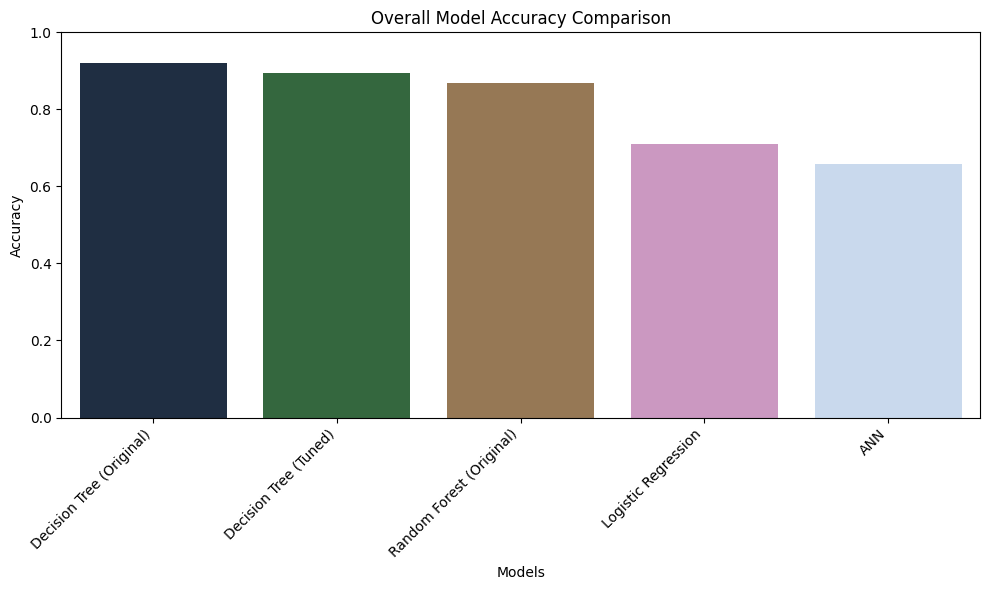

In [118]:
all_accuracies = {
    'Decision Tree (Original)': acc_dt_original,
    'Decision Tree (Tuned)': accuracy_dt_tuned,
    'Logistic Regression': acc_lr,
    'Random Forest (Original)': acc_rf_original,
    'ANN': acc_ann
}

accuracy_results_df = pd.DataFrame(list(all_accuracies.items()), columns=['Model', 'Accuracy'])
accuracy_results_df = accuracy_results_df.sort_values(by='Accuracy', ascending=False)

print("\nOverall Model Accuracy Comparison:\n")
display(accuracy_results_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=accuracy_results_df, palette='cubehelix')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Overall Model Accuracy Comparison')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 8.2 Precision and Recall Comparison

,Model,Precision,Recall
0,Decision Tree (Original),0.917544,0.921053
1,Decision Tree (Tuned),0.882775,0.894737
2,Logistic Regression,0.693381,0.710526
3,Random Forest (Original),0.794737,0.868421
4,Random Forest (Tuned),0.794737,0.868421
5,ANN,0.631579,0.657895


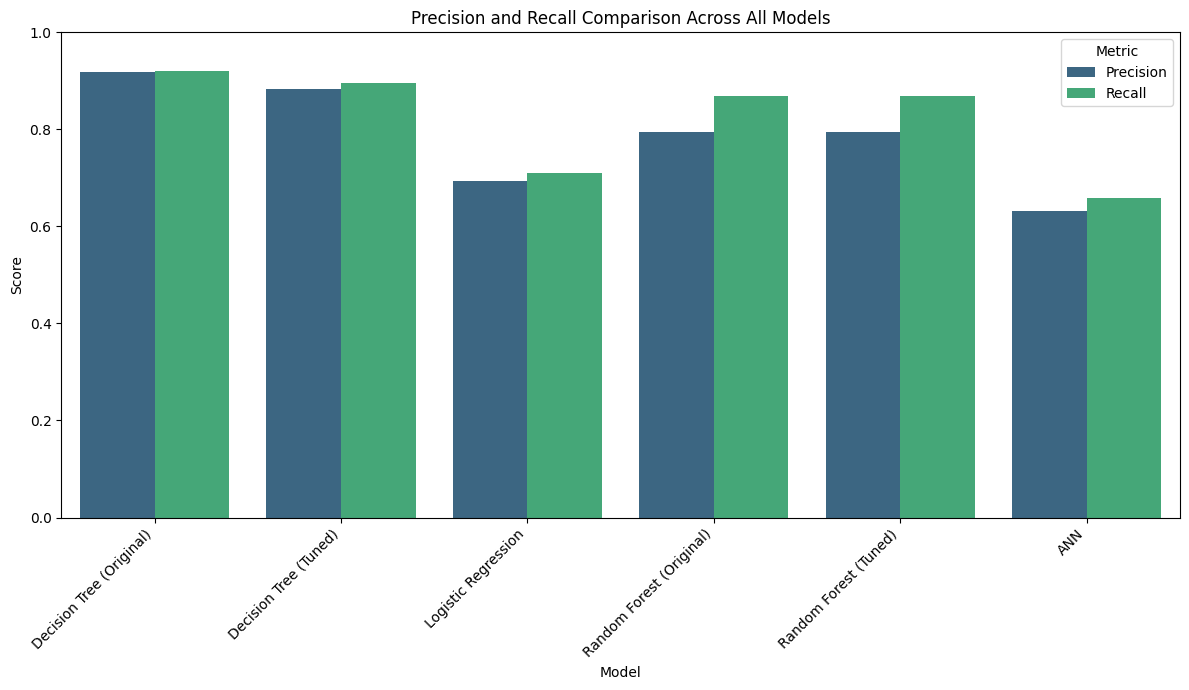

In [119]:
all_precision_recall_data = {
    'Model': [
        'Decision Tree (Original)',
        'Decision Tree (Tuned)',
        'Logistic Regression',
        'Random Forest (Original)',
        'Random Forest (Tuned)',
        'ANN'
    ],
    'Precision': [
        precision_dt_original,
        precision_dt_tuned,
        precision_lr,
        precision_rf_original,
        precision_rf_tuned,
        precision_ann
    ],
    'Recall': [
        recall_dt_original,
        recall_dt_tuned,
        recall_lr,
        recall_rf_original,
        recall_rf_tuned,
        recall_ann
    ]
}

precision_recall_df_all = pd.DataFrame(all_precision_recall_data)
display(precision_recall_df_all)

precision_recall_melted_all = precision_recall_df_all.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=precision_recall_melted_all, palette='viridis')
plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Precision and Recall Comparison Across All Models')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 9. Decision Tree Visualization (Tuned Model)

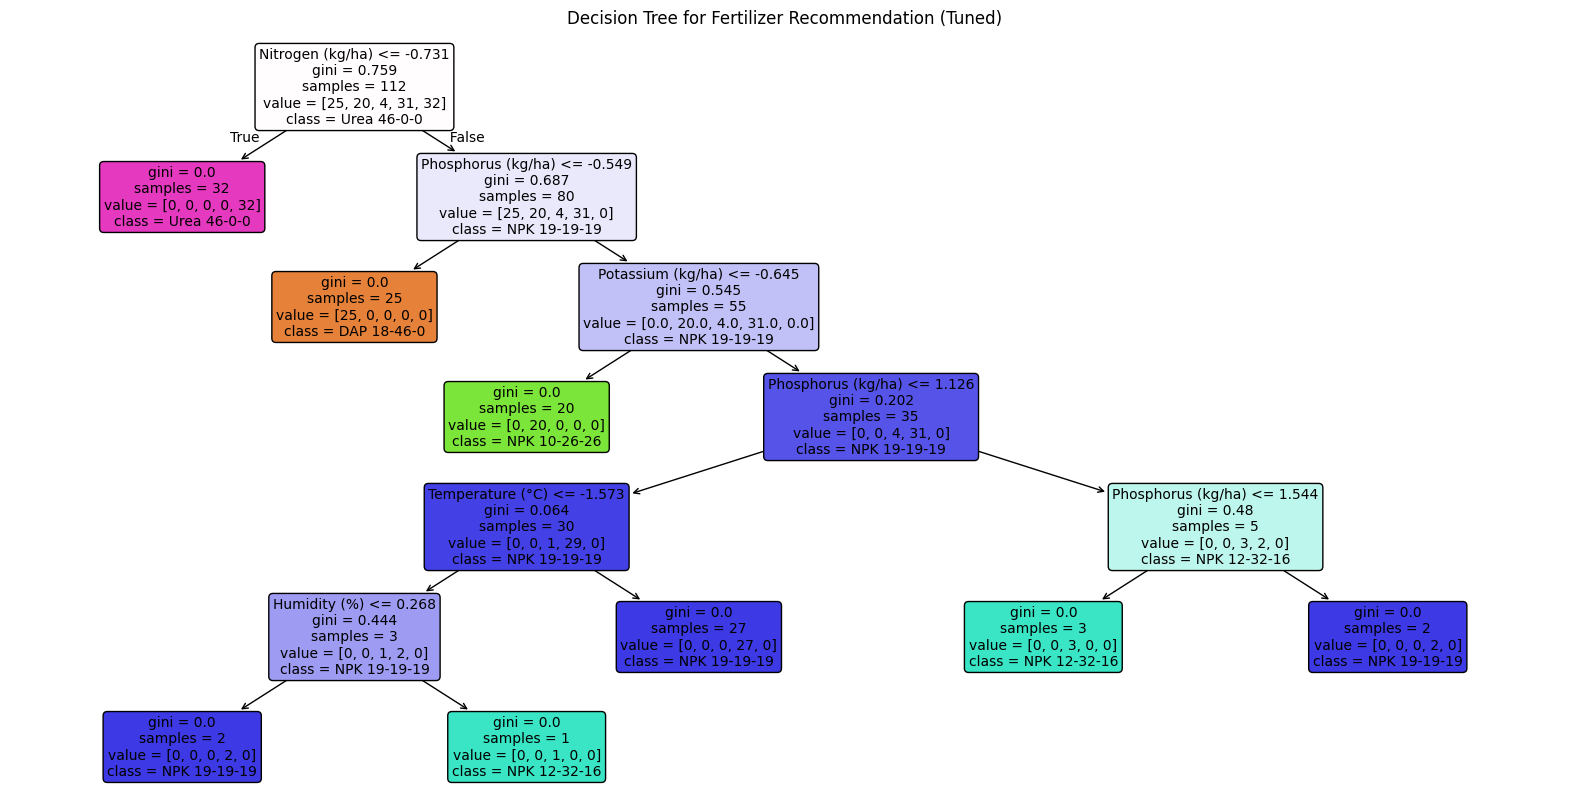

In [120]:
plt.figure(figsize=(20,10))
plot_tree(
    model_dt_tuned, # Using the tuned Decision Tree model
    filled=True,
    feature_names=['Temperature (°C)', 'Humidity (%)', 'Soil Moisture (%)',
             'Soil Type', 'Crop Type',
             'Nitrogen (kg/ha)', 'Phosphorus (kg/ha)', 'Potassium (kg/ha)'],
    class_names=np.unique(Y), # Use unique values from the target variable Y
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree for Fertilizer Recommendation (Tuned)")
plt.show()

## 10. Making a New Prediction

In [121]:
# Example prediction using the best performing model (Tuned Random Forest in this case)
soil_input = 'Red'
crop_input = 'Sugarcane'

soil_num = le_soil.transform([soil_input])[0]
crop_num = le_crop.transform([crop_input])[0]

new_data_input = [[21, 62, 30, soil_num, crop_num, 26, 17, 39]]

new_data_scaled = sc_X.transform(new_data_input)

prediction_rf_tuned = model_rf_tuned.predict(new_data_scaled)

print("Recommended Fertilizer (using Tuned Random Forest):", prediction_rf_tuned[0])

Recommended Fertilizer (using Tuned Random Forest): Urea 46-0-0
